## Install OCR Libraries

In [ ]:
#pip install easyocr

In [1]:
import easyocr

In [12]:
image_path = 'gas.jpg'

reader = easyocr.Reader(['en'], gpu=False) # Specify language(s)
results = reader.readtext(image_path)
#extracted_text = "\n".join([res[1] for res in results]) # Extract only the text
print(results)

Using CPU. Note: This module is much faster with a GPU.
d:\Projects\ai-projects\ocr-gas-receipt-extraction\env\lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[([[np.int32(322), np.int32(350)], [np.int32(673), np.int32(350)], [np.int32(673), np.int32(447)], [np.int32(322), np.int32(447)]], 'Wholesale', np.float64(0.9998570232146867)), ([[np.int32(298), np.int32(433)], [np.int32(379), np.int32(433)], [np.int32(379), np.int32(489)], [np.int32(298), np.int32(489)]], '10', np.float64(0.9999902219451473)), ([[np.int32(398), np.int32(430)], [np.int32(706), np.int32(430)], [np.int32(706), np.int32(516)], [np.int32(398), np.int32(516)]], 'Langford', np.float64(0.9999792215142663)), ([[np.int32(732), np.int32(445)], [np.int32(810), np.int32(445)], [np.int32(810), np.int32(502)], [np.int32(732), np.int32(502)]], 'Dr', np.float64(0.9983770579844955)), ([[np.int32(145), np.int32(482)], [np.int32(422), np.int32(482)], [np.int32(422), np.int32(568)], [np.int32(145), np.int32(568)]], 'Marsden', np.float64(0.9999949986826923)), ([[np.int32(445), np.int32(509)], [np.int32(596), np.int32(509)], [np.int32(596), np.int32(566)], [np.int32(445), np.int32(566)]], 

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


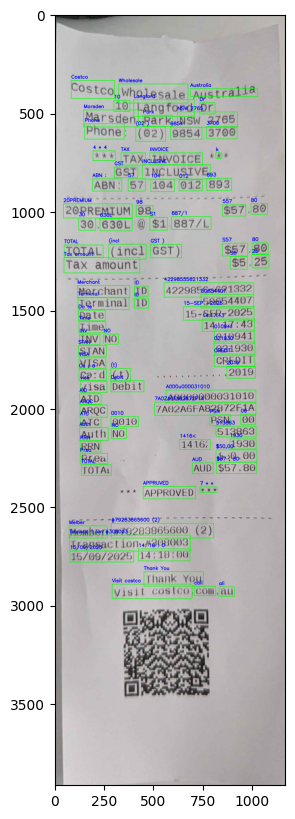

In [14]:
import cv2
import matplotlib.pyplot as plt
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
for (bbox, text, prob) in results:
    (top_left, top_right, bottom_right, bottom_left) = bbox
    top_left = (int(top_left[0]), int(top_left[1]))
    bottom_right = (int(bottom_right[0]), int(bottom_right[1]))
    image = cv2.rectangle(image, top_left, bottom_right, (0, 255, 0), 2)
    image = cv2.putText(image, text, (top_left[0], top_left[1] - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    
plt.figure(figsize=(10,10))
plt.imshow(image)